In [22]:
import random
import torch
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
def synthetic_data(w, b, num_examples):
  """生成y = Xw + b + noise"""
  X = torch.normal(0, 1, (num_examples, len(w)))
  y = torch.matmul(X, w) + b
  y += torch.normal(0, 0.01, y.shape)
  return X, y.reshape((-1, 1))
  # 行向量转换为列向量

In [20]:
true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

In [21]:
labels[:5]

tensor([[6.9786],
        [2.9928],
        [3.4783],
        [8.1099],
        [4.0983]])

In [30]:
features.shape

torch.Size([1000, 2])

In [31]:
labels.shape

torch.Size([1000, 1])

由于features对应的是两个权重，因此它有两列，而labels只有一列，在绘图的时候必须选取features中的一列才能完成绘图。

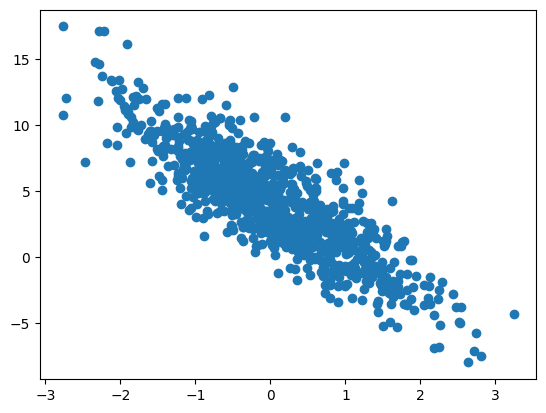

In [25]:
fig, ax = plt.subplots()
ax.scatter(features[:,1].detach().numpy(), labels.detach().numpy())

In [33]:
def data_iter(batch_size, features, labels):
  num_examples = len(features)
  indices = list(range(num_examples))
  random.shuffle(indices)
  for i in range(0, num_examples, batch_size):
    batch_indices = torch.tensor(indices[i:min(i+batch_size, num_examples)])
    yield features[batch_indices], labels[batch_indices]

In [34]:
batch_size = 10

In [36]:
w = torch.normal(0,0.01, size=(2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

In [38]:
def linreg(X, w, b):
  """线性回归模型"""
  return torch.matmul(X, w) + b

In [39]:
def squared_loss(y_hat, y):
  """均方损失"""
  return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

In [40]:
def sgd(params, lr, batch_size):
  """小批量随机梯度下降"""
  with torch.no_grad():
    for param in params:
      param -= lr * param.grad / batch_size
      param.grad.zero_()

In [41]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
  for X, y in data_iter(batch_size, features, labels):
    l = loss(net(X, w, b), y)
    l.sum().backward()
    sgd([w, b], lr, batch_size)
  with torch.no_grad():
    train_1 = loss(net(features, w, b), labels)
    print(f"epoch {epoch + 1}, loss {float(train_1.mean()):f}")

epoch 1, loss 0.043508
epoch 2, loss 0.000177
epoch 3, loss 0.000052


In [43]:
print(true_w - w.reshape(true_w.shape))
print(true_b - b)

tensor([ 0.0005, -0.0011], grad_fn=<SubBackward0>)
tensor([0.0001], grad_fn=<RsubBackward1>)


以下为简洁实现，即调用pytorch中已经存在的modual或functions

In [44]:
from torch.utils import data

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

In [46]:
def load_array(data_arrays, batch_size, is_train=True):
  """构造pytorch迭代器"""
  dataset = data.TensorDataset(*data_arrays)
  return data.DataLoader(dataset, batch_size, shuffle=is_train)

In [47]:
batch_size = 10
data_iter = load_array((features, labels), batch_size)

In [48]:
next(iter(data_iter))

[tensor([[ 0.5994,  0.1470],
         [-0.7932,  0.1965],
         [-0.3654,  0.7923],
         [-0.1942,  0.7153],
         [-0.2637, -0.7637],
         [-0.4386, -1.3461],
         [ 0.4003, -0.3521],
         [ 1.1289,  0.8061],
         [ 0.1508, -0.6527],
         [-0.4711,  0.5232]]),
 tensor([[4.9021],
         [1.9554],
         [0.7629],
         [1.3580],
         [6.2725],
         [7.8957],
         [6.1997],
         [3.7195],
         [6.7253],
         [1.4707]])]

In [49]:
from torch import nn

In [51]:
net = nn.Sequential(nn.Linear(2, 1))

In [52]:
net[0].weight.data.normal_(0,0.01)
net[0].bias.data.fill_(0)

tensor([0.])

In [53]:
loss = nn.MSELoss()

In [54]:
trainer = torch.optim.SGD(net.parameters(), lr=0.03)

In [55]:
num_epochs = 3
for epoch in range(num_epochs):
  for X, y in data_iter:
    l = loss(net(X), y)
    trainer.zero_grad()
    l.backward()
    trainer.step()
  l = loss(net(features), labels)
  print(f"epoch {epoch + 1}, loss{l:f}")

epoch 1, loss0.000707
epoch 2, loss0.000097
epoch 3, loss0.000096
